# Part 3: NLP Text Classification

## Objective

The objective of this project is to classify customer support messages into positive, neutral, and negative sentiment categories using NLP techniques and deep learning models.

In [1]:
# Import Libraries

In [2]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords')

print("Libraries Imported Successfully")

Libraries Imported Successfully


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shivi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Dataset Loading

In [3]:
# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv(
    "data/customer_support_text_classification.csv"
)

print("Dataset Shape:", df.shape)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/customer_support_text_classification.csv'

# Dataset Exploration

print(df.columns)

print(df.info())

# Sentiment Distribution

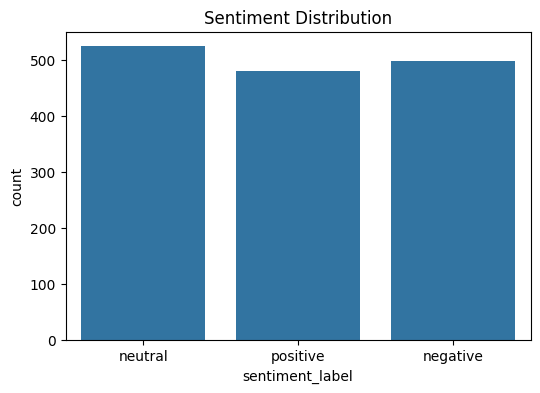

In [ ]:
import os

os.makedirs("results", exist_ok=True)

plt.figure(figsize=(6,4))

sns.countplot(x=df['sentiment_label'])

plt.title("Sentiment Distribution")

plt.savefig("results/sentiment_distribution.png")

plt.show()

In [ ]:
# Text Cleaning

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['cleaned_text'] = df['customer_message'].apply(clean_text)

df[['customer_message', 'cleaned_text']].head()

,customer_message,cleaned_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


# TF-IDF Vectorization

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(
    df['cleaned_text']
).toarray()

encoder = LabelEncoder()

y = encoder.fit_transform(
    df['sentiment_label']
)

print("Feature Shape:", X.shape)

Feature Shape: (1500, 146)


# Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (1200, 146)
Testing Shape: (300, 146)


# Baseline NLP Model

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



# Confusion Matrix

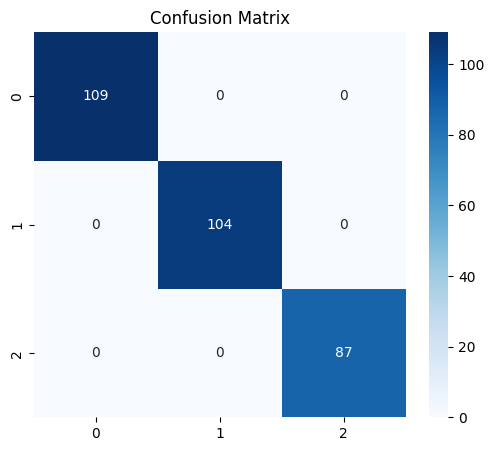

In [ ]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.savefig("results/confusion_matrix.png")

plt.show()

# Deep Learning NLP Model using LSTM

In [ ]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(
    df['cleaned_text']
)

X_seq = pad_sequences(
    sequences,
    maxlen=100
)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y,
    test_size=0.2,
    random_state=42
)

deep_model = Sequential([

    Embedding(
        5000,
        64,
        input_length=100
    ),

    LSTM(64),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        3,
        activation='softmax'
    )

])

deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = deep_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5


c:\Users\shivi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6281 - loss: 1.0000 - val_accuracy: 0.9042 - val_loss: 0.6975
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9719 - loss: 0.2790 - val_accuracy: 0.9833 - val_loss: 0.1961
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 1.0000 - loss: 0.0443 - val_accuracy: 1.0000 - val_loss: 0.0079
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 0.0018


# Accuracy Curve

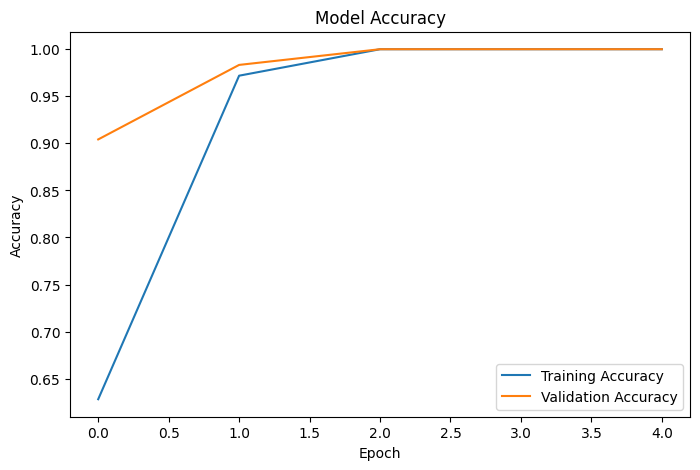

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.savefig("results/accuracy_curve.png")

plt.show()